In [15]:
import sys
!{sys.executable} -m pip install -r "C:\Users\ASMITA\Desktop\mlproject\requirements.txt"

import warnings
warnings.filterwarnings("ignore")

  Using cached pandas-2.0.3-cp38-cp38-win_amd64.whl.metadata (18 kB)
  Using cached numpy-1.24.4-cp38-cp38-win_amd64.whl.metadata (5.6 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.7.5-cp38-cp38-win_amd64.whl.metadata (5.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/10.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.8 MB ? eta -:--:--
    ------------------------

In [17]:
import pandas as pd
df=pd.read_csv("stud.csv")
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [18]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [23]:
numeric_features=[x for x in df.columns if df[x].dtype!='O']
categoric_features=[x for x in df.columns if x not in numeric_features]

In [26]:
df.isnull().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [29]:
df.duplicated().sum()

0

In [30]:
df['total_score']=df['math_score']+df['reading_score']+df['writing_score']
df['avg_score']=df['total_score']/3

In [31]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,avg_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [34]:
for x in categoric_features:
    print(f"Categories in {x} are {df[x].unique()}")

Categories in gender are ['female' 'male']
Categories in race_ethnicity are ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in parental_level_of_education are ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in lunch are ['standard' 'free/reduced']
Categories in test_preparation_course are ['none' 'completed']


In [43]:
full_reading_score=(df['reading_score']==100).sum()
print("No. of students who got full marks in reading = ",full_reading_score)
full_math_score=(df['math_score']==100).sum()
print("No. of students who got full marks in math = ",full_math_score)
full_writing_score=(df['writing_score']==100).sum()
print("No. of students who got full marks in writing = ",full_writing_score)

No. of students who got full marks in reading =  17
No. of students who got full marks in math =  7
No. of students who got full marks in writing =  14


In [44]:
lessthan20_reading_score=(df['reading_score']<=20).sum()
print("No. of students who got <=20 marks in reading = ",lessthan20_reading_score)
lessthan20_math_score=(df['math_score']<=20).sum()
print("No. of students who got <=20 marks in math = ",lessthan20_math_score)
lessthan20_writing_score=(df['writing_score']<=20).sum()
print("No. of students who got <=20 marks in writing = ",lessthan20_writing_score)

No. of students who got <=20 marks in reading =  1
No. of students who got <=20 marks in math =  4
No. of students who got <=20 marks in writing =  3


In [ ]:
# Data Visualization

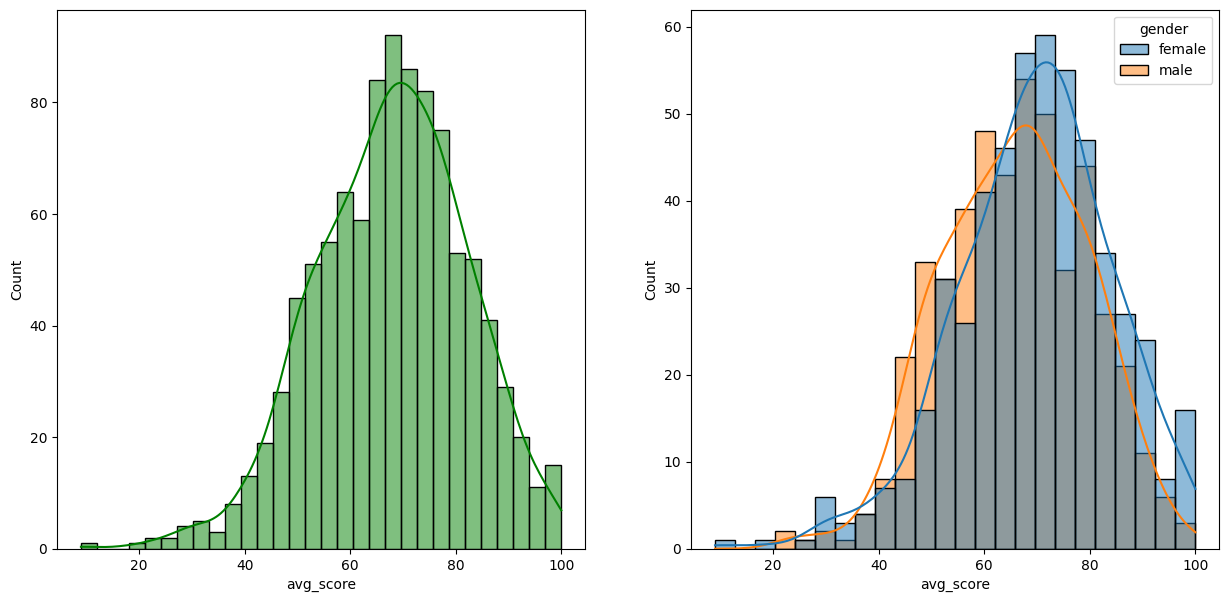

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axs=plt.subplots(1,2,figsize=(15,7))
sns.histplot(data=df, x='avg_score', color='g',bins=30, kde=True, ax=axs[0])
sns.histplot(data=df, x='avg_score', hue='gender', kde=True, ax=axs[1])
plt.show()

#girls performed better in average score

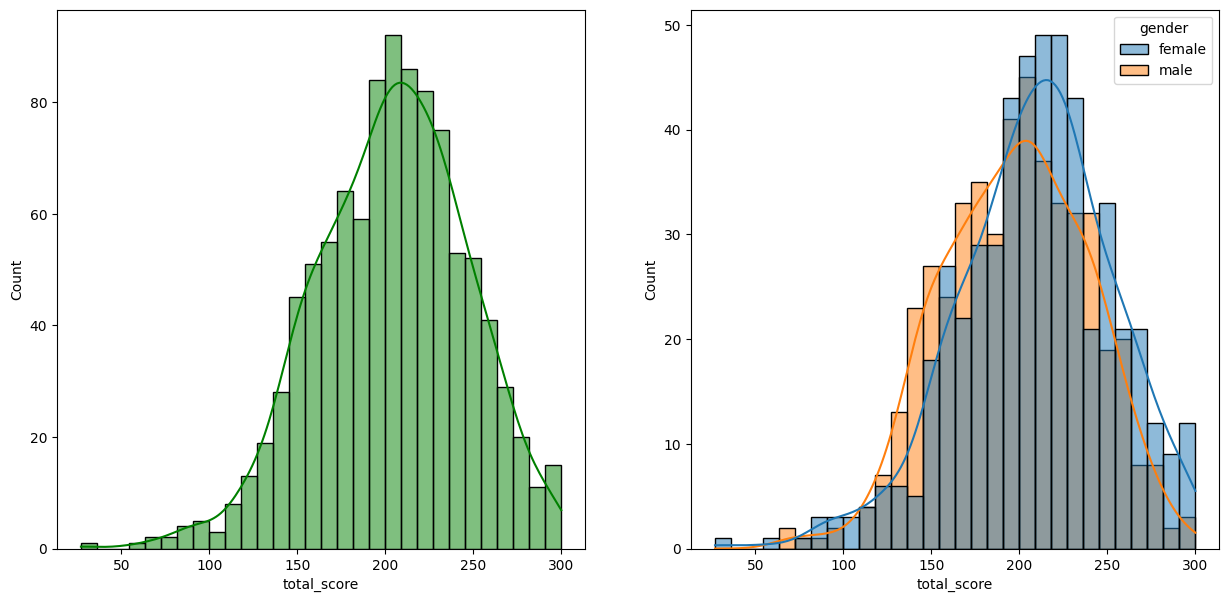

In [ ]:
fig, axs=plt.subplots(1,2,figsize=(15,7))
sns.histplot(data=df, x='total_score', color='g', bins=30, kde=True, ax=axs[0])
sns.histplot(data=df, x='total_score', hue='gender', bins=30, kde=True, ax=axs[1])
plt.show()

#female performed better in total score

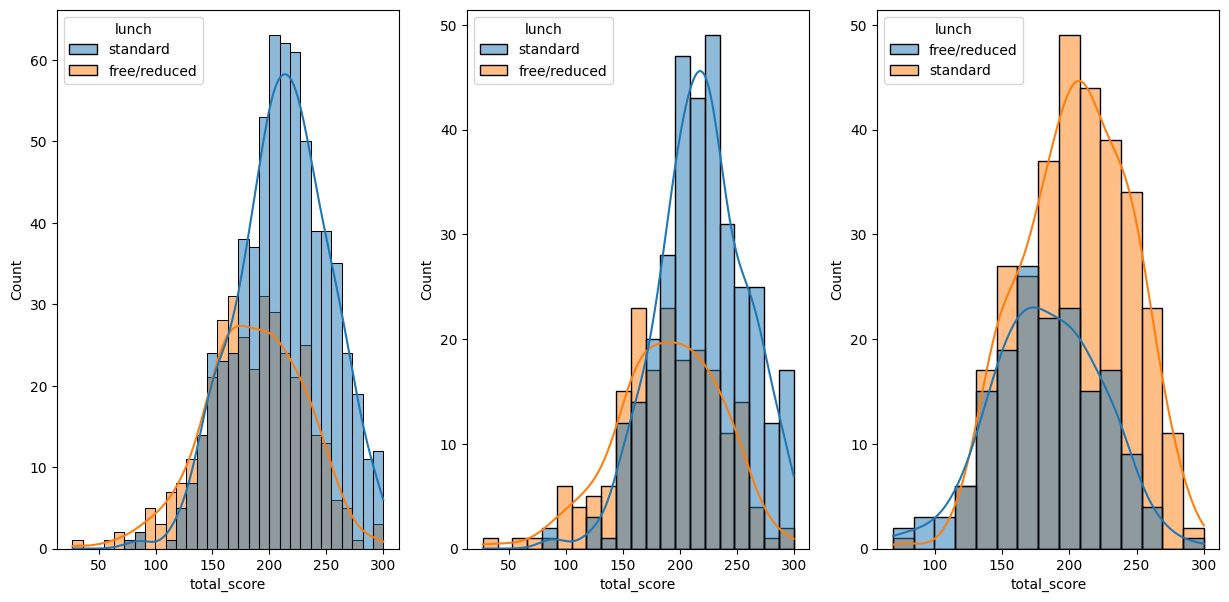

In [57]:
fig, axs=plt.subplots(1,3,figsize=(15,7))
sns.histplot(data=df, x='total_score', hue='lunch', kde=True, bins=30, ax=axs[0])
sns.histplot(data=df[df['gender']=='female'], x='total_score', hue='lunch', kde=True, ax=axs[1])
sns.histplot(data=df[df['gender']=='male'], x='total_score', hue='lunch', kde=True, ax=axs[2])
plt.show()

#standard lunch works better to boost scores

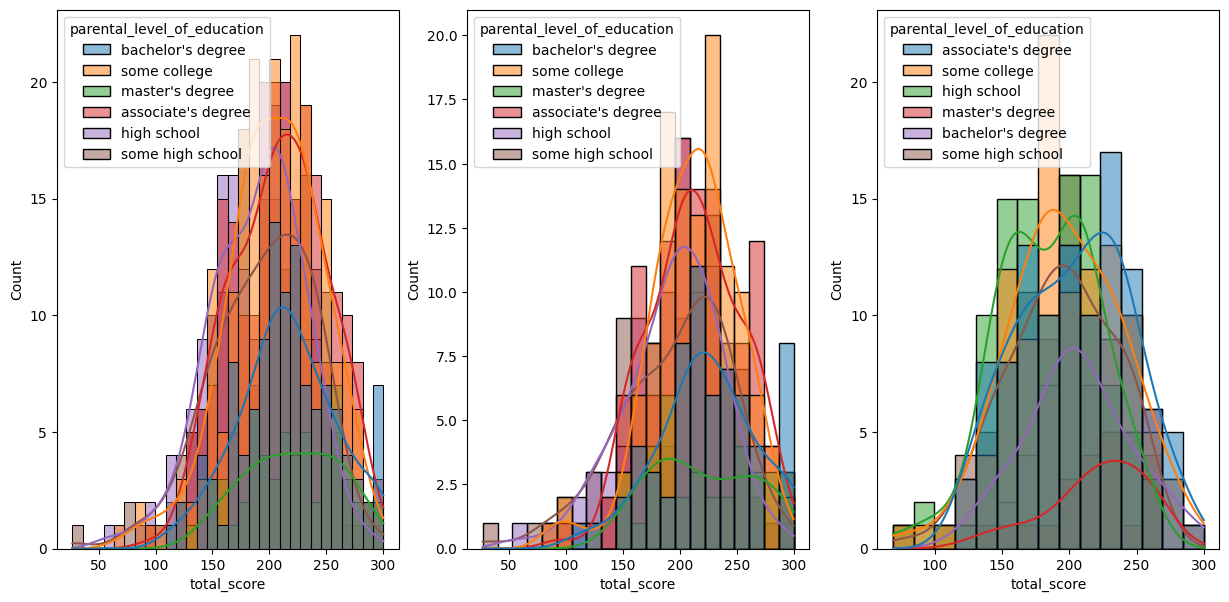

In [ ]:
fig, axs=plt.subplots(1,3,figsize=(15,7))
sns.histplot(data=df, x='total_score', hue='parental_level_of_education', kde=True, bins=30, ax=axs[0])
sns.histplot(data=df[df['gender']=='female'], x='total_score', hue='parental_level_of_education', kde=True, ax=axs[1])
sns.histplot(data=df[df['gender']=='male'], x='total_score', hue='parental_level_of_education', kde=True, ax=axs[2])
plt.show()

#in general parents education doesnt matter too much

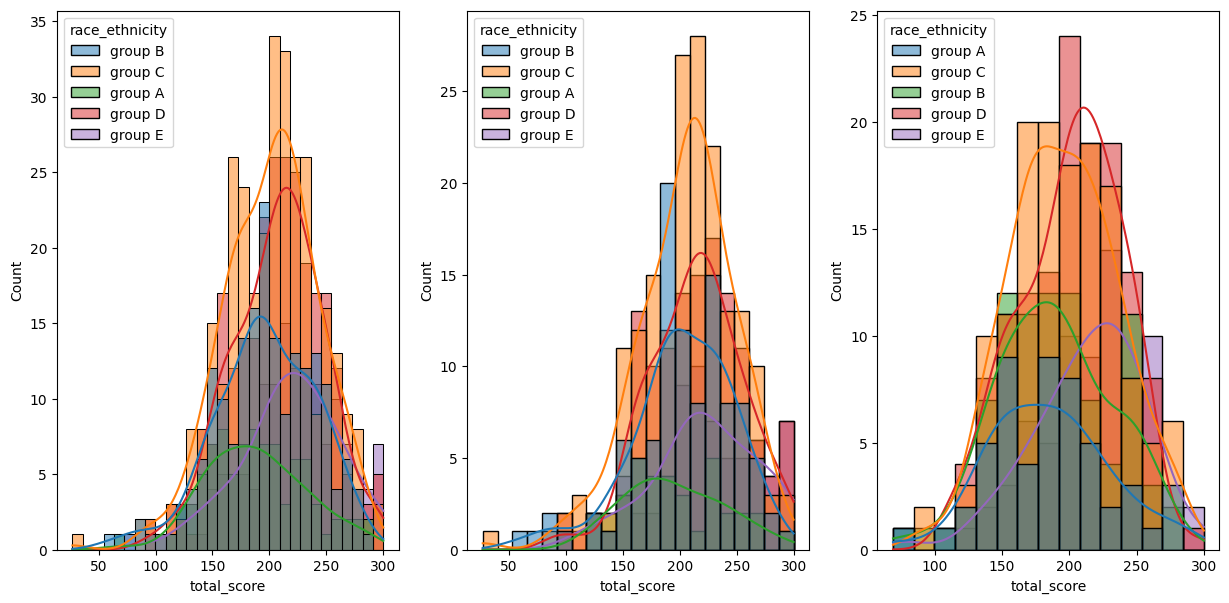

In [ ]:
fig, axs=plt.subplots(1,3,figsize=(15,7))
sns.histplot(data=df, x='total_score', hue='race_ethnicity', kde=True, bins=30, ax=axs[0])
sns.histplot(data=df[df['gender']=='female'], x='total_score', hue='race_ethnicity', kde=True, ax=axs[1])
sns.histplot(data=df[df['gender']=='male'], x='total_score', hue='race_ethnicity', kde=True, ax=axs[2])
plt.show()

#group C and group D students perform better

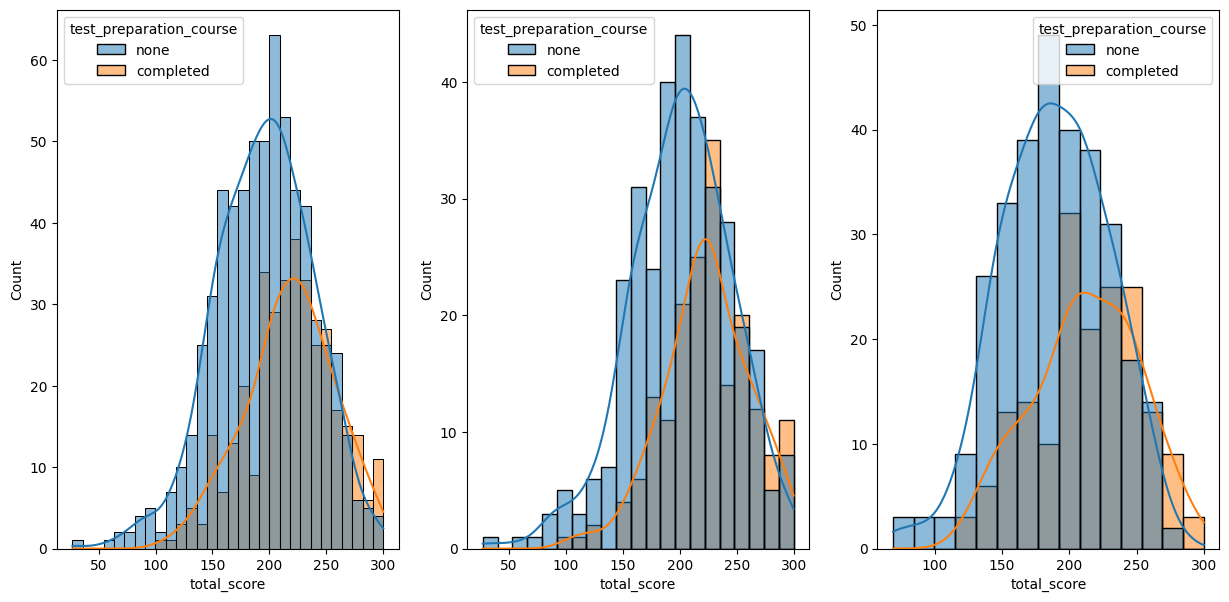

In [60]:
fig, axs=plt.subplots(1,3,figsize=(15,7))
sns.histplot(data=df, x='total_score', hue='test_preparation_course', kde=True, bins=30, ax=axs[0])
sns.histplot(data=df[df['gender']=='female'], x='total_score', hue='test_preparation_course', kde=True, ax=axs[1])
sns.histplot(data=df[df['gender']=='male'], x='total_score', hue='test_preparation_course', kde=True, ax=axs[2])
plt.show()

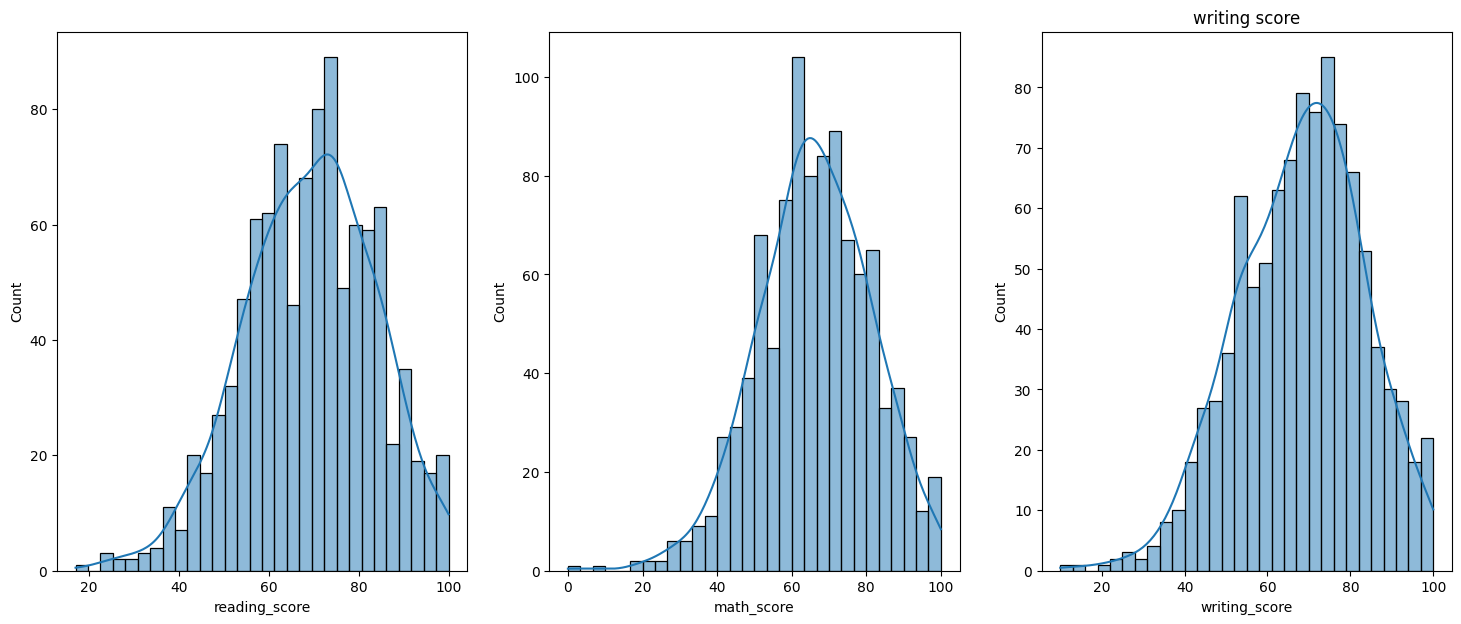

In [62]:
fig, axs=plt.subplots(1,3,figsize=(18,7))
plt.title("reading score")
sns.histplot(x='reading_score', data=df, bins=30, kde=True, ax=axs[0])
plt.title("math score")
sns.histplot(x='math_score', data=df, bins=30, kde=True, ax=axs[1])
plt.title("writing score")
sns.histplot(x='writing_score', data=df, bins=30, kde=True, ax=axs[2])
plt.show()

In [75]:
df['lunch'].value_counts()

lunch
standard        645
free/reduced    355
Name: count, dtype: int64

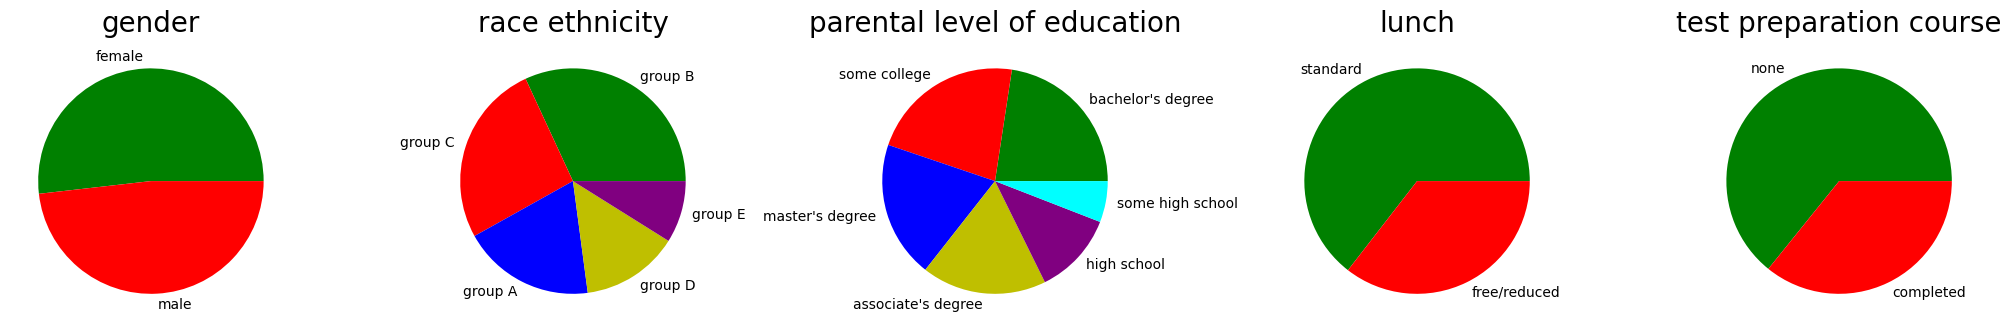

In [80]:
fig, axs=plt.subplots(1,5,figsize=(20,5))
size=df['gender'].value_counts()
labels=df['gender'].unique()
colors=['g','r']
plt.subplot(1,5,1)
plt.pie(size, labels=labels, colors=colors)
plt.title("gender", fontsize=20)


size=df['race_ethnicity'].value_counts()
labels=df['race_ethnicity'].unique()
colors=['g','r','b','y','purple']
plt.subplot(1,5,2)
plt.pie(size, labels=labels, colors=colors)
plt.title("race ethnicity", fontsize=20)


size=df['parental_level_of_education'].value_counts()
labels=df['parental_level_of_education'].unique()
colors=['g','r','b','y','purple','cyan']
plt.subplot(1,5,3)
plt.pie(size, labels=labels, colors=colors)
plt.title("parental level of education", fontsize=20)


size=df['lunch'].value_counts()
labels=df['lunch'].unique()
colors=['g','r']
plt.subplot(1,5,4)
plt.pie(size, labels=labels, colors=colors)
plt.title("lunch", fontsize=20)



size=df['test_preparation_course'].value_counts()
labels=df['test_preparation_course'].unique()
colors=['g','r']
plt.subplot(1,5,5)
plt.pie(size, labels=labels, colors=colors)
plt.title("test preparation course", fontsize=20)

plt.tight_layout()
plt.show()

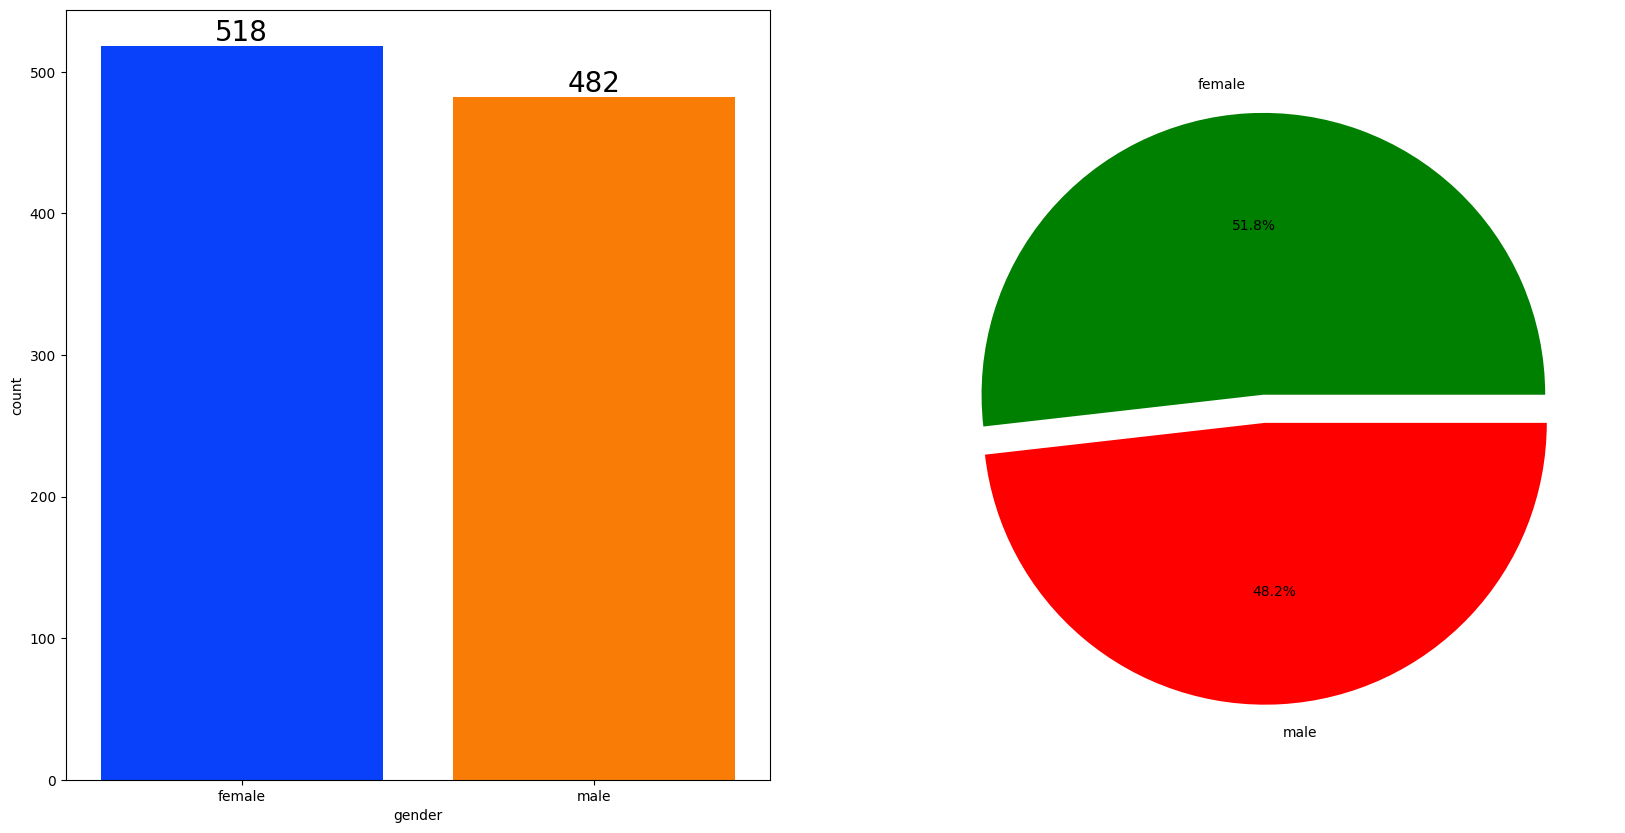

In [85]:
fig, axs=plt.subplots(1,2,figsize=(20,10))
sns.countplot(data=df, x='gender', palette='bright', ax=axs[0], saturation=0.95)
for container in axs[0].containers:
    axs[0].bar_label(container, size=20)

plt.pie(x=df['gender'].value_counts(), labels=df['gender'].unique(), colors=['g','r'], explode=[0,0.1], autopct="%1.1f%%")
plt.show()

In [100]:
math_group=df.groupby('gender')['math_score'].mean()
reading_group=df.groupby('gender')['reading_score'].mean()
writing_group=df.groupby('gender')['writing_score'].mean()


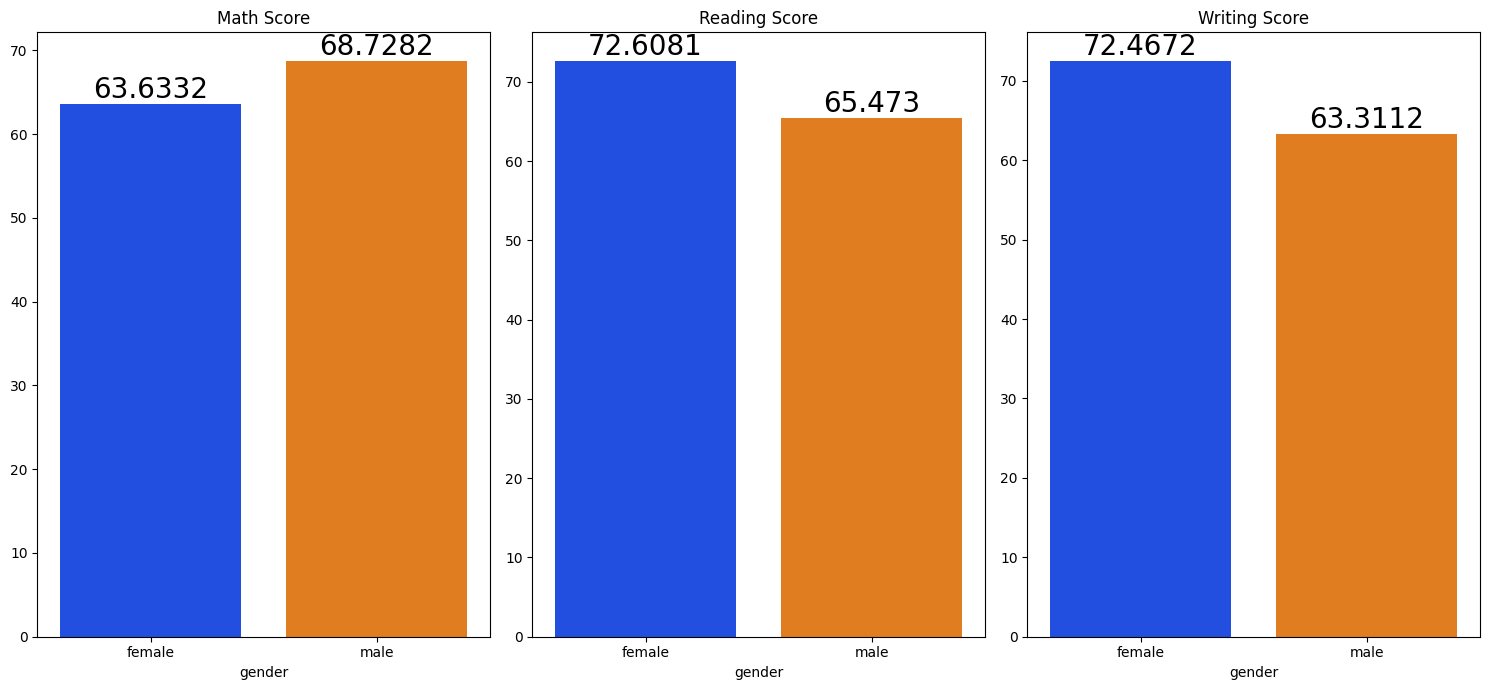

In [103]:
fig, axs=plt.subplots(1,3,figsize=(15,7))
plt.subplot(1,3,1)
plt.title("Math Score")
sns.barplot(x=math_group.index,y=math_group.values, palette='bright', ax=axs[0])

for container in axs[0].containers:
    axs[0].bar_label(container, color='black', size=20)


plt.subplot(1,3,2)
plt.title("Reading Score")
sns.barplot(x=reading_group.index,y=reading_group.values, palette='bright', ax=axs[1])

for container in axs[1].containers:
    axs[1].bar_label(container, color='black', size=20)

plt.subplot(1,3,3)
plt.title("Writing Score")
sns.barplot(x=writing_group.index,y=writing_group.values, palette='bright', ax=axs[2])

for container in axs[2].containers:
    axs[2].bar_label(container, color='black', size=20)


plt.tight_layout()
plt.show()

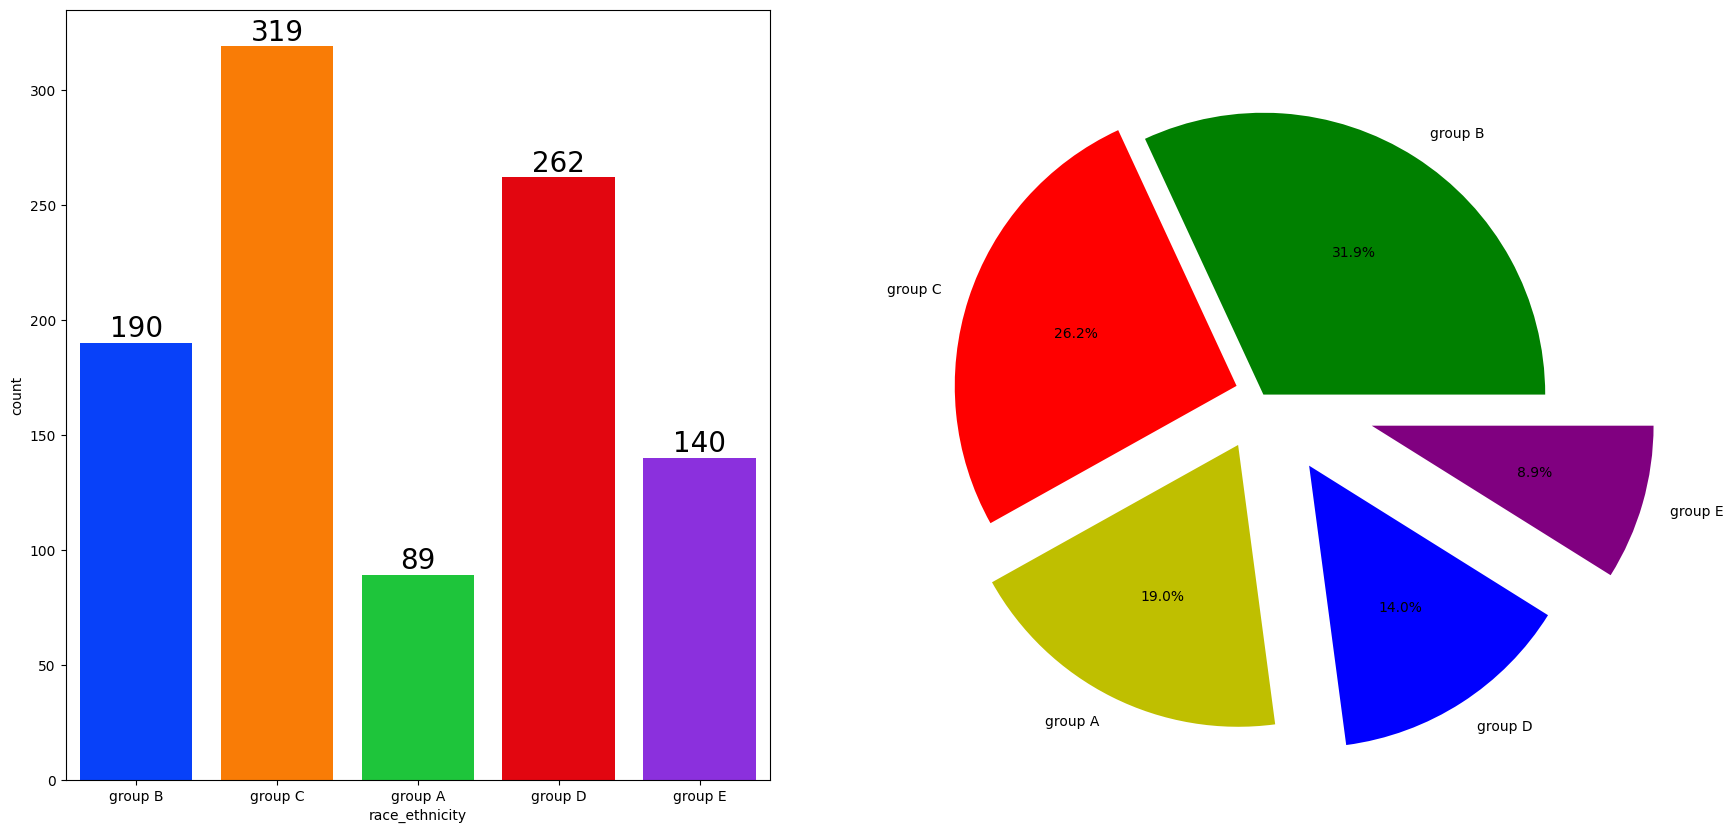

In [106]:
fig, axs=plt.subplots(1,2,figsize=(20,10))
sns.countplot(data=df, x='race_ethnicity', palette='bright', ax=axs[0], saturation=0.95)
for container in axs[0].containers:
    axs[0].bar_label(container, size=20)

plt.pie(x=df['race_ethnicity'].value_counts(), labels=df['race_ethnicity'].unique(), colors=['g','r','y','b','purple'], explode=[0,0.1,0.2,0.3,0.4], autopct="%1.1f%%")
plt.show()

In [107]:
math_group=df.groupby('race_ethnicity')['math_score'].mean()
reading_group=df.groupby('race_ethnicity')['reading_score'].mean()
writing_group=df.groupby('race_ethnicity')['writing_score'].mean()

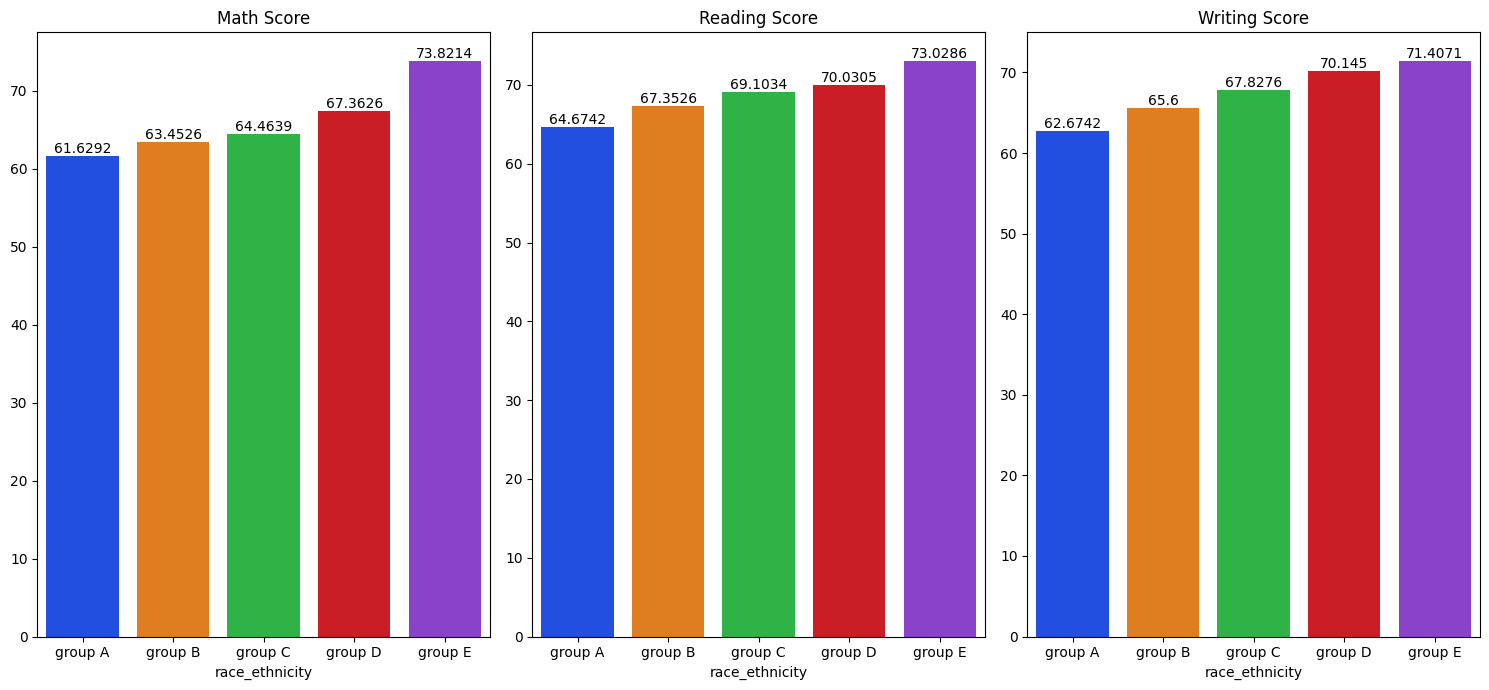

In [109]:
fig, axs=plt.subplots(1,3,figsize=(15,7))
plt.subplot(1,3,1)
plt.title("Math Score")
sns.barplot(x=math_group.index,y=math_group.values, palette='bright', ax=axs[0])

for container in axs[0].containers:
    axs[0].bar_label(container, color='black', size=10)


plt.subplot(1,3,2)
plt.title("Reading Score")
sns.barplot(x=reading_group.index,y=reading_group.values, palette='bright', ax=axs[1])

for container in axs[1].containers:
    axs[1].bar_label(container, color='black', size=10)

plt.subplot(1,3,3)
plt.title("Writing Score")
sns.barplot(x=writing_group.index,y=writing_group.values, palette='bright', ax=axs[2])

for container in axs[2].containers:
    axs[2].bar_label(container, color='black', size=10)


plt.tight_layout()
plt.show()

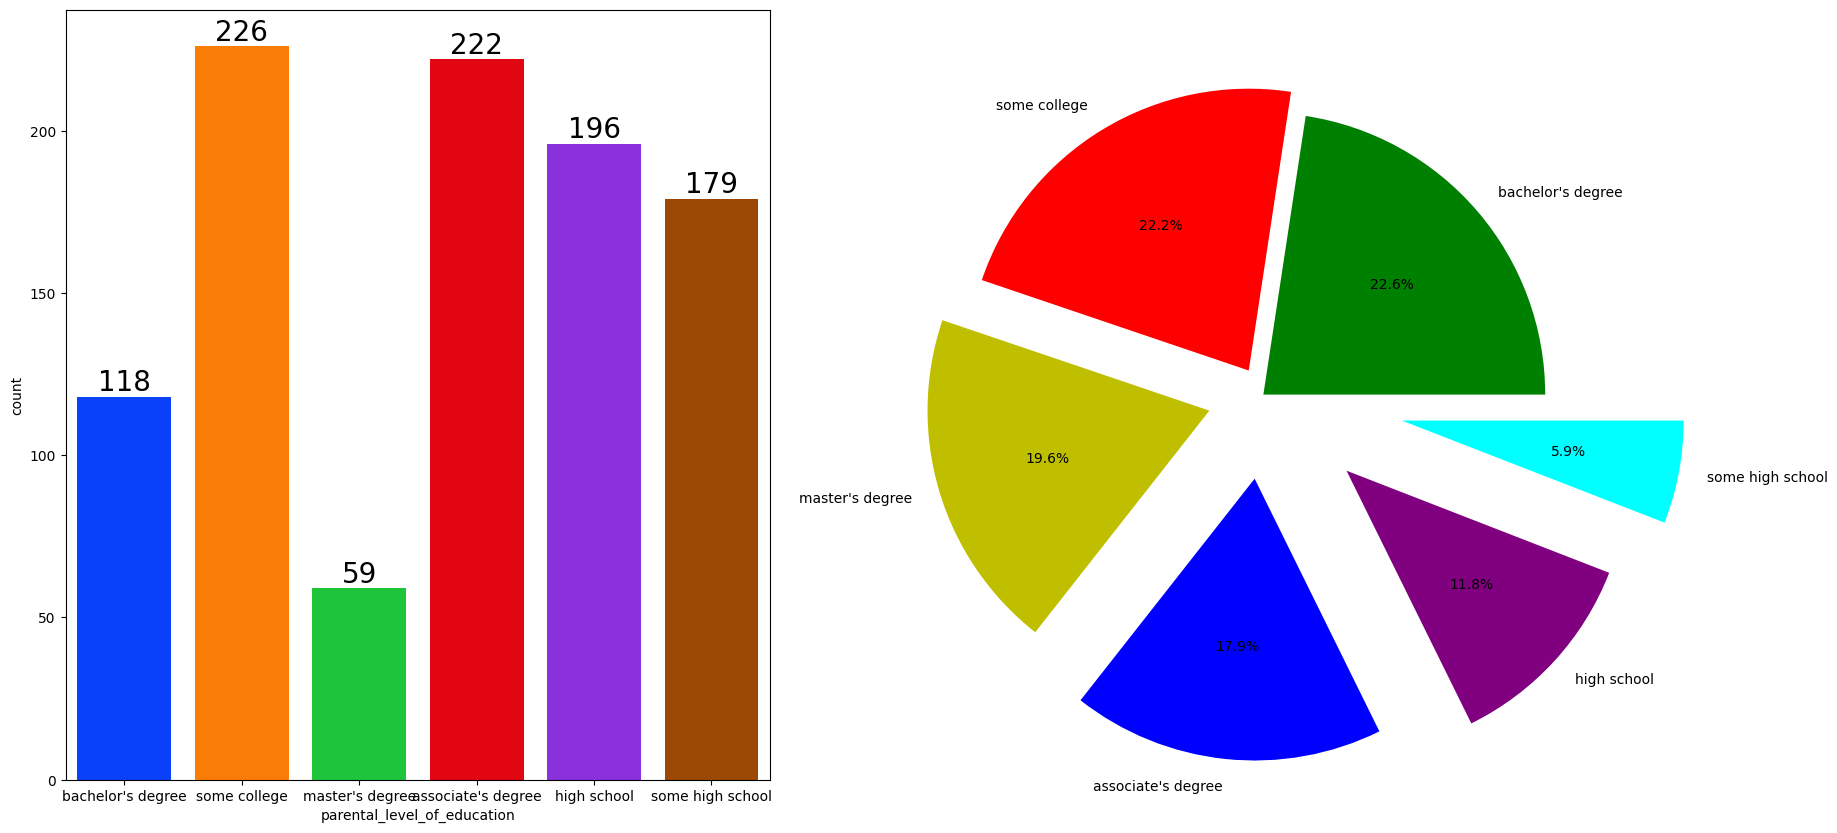

In [117]:
fig, axs=plt.subplots(1,2,figsize=(20,10))
sns.countplot(data=df, x='parental_level_of_education', palette='bright', ax=axs[0], saturation=0.95)
for container in axs[0].containers:
    axs[0].bar_label(container, size=20)

plt.pie(x=df['parental_level_of_education'].value_counts(), labels=df['parental_level_of_education'].unique(), colors=['g','r','y','b','purple','cyan'], explode=[0,0.1,0.2,0.3,0.4,0.5], autopct="%1.1f%%")
plt.show()

In [118]:
math_group=df.groupby('parental_level_of_education')['math_score'].mean()
reading_group=df.groupby('parental_level_of_education')['reading_score'].mean()
writing_group=df.groupby('parental_level_of_education')['writing_score'].mean()

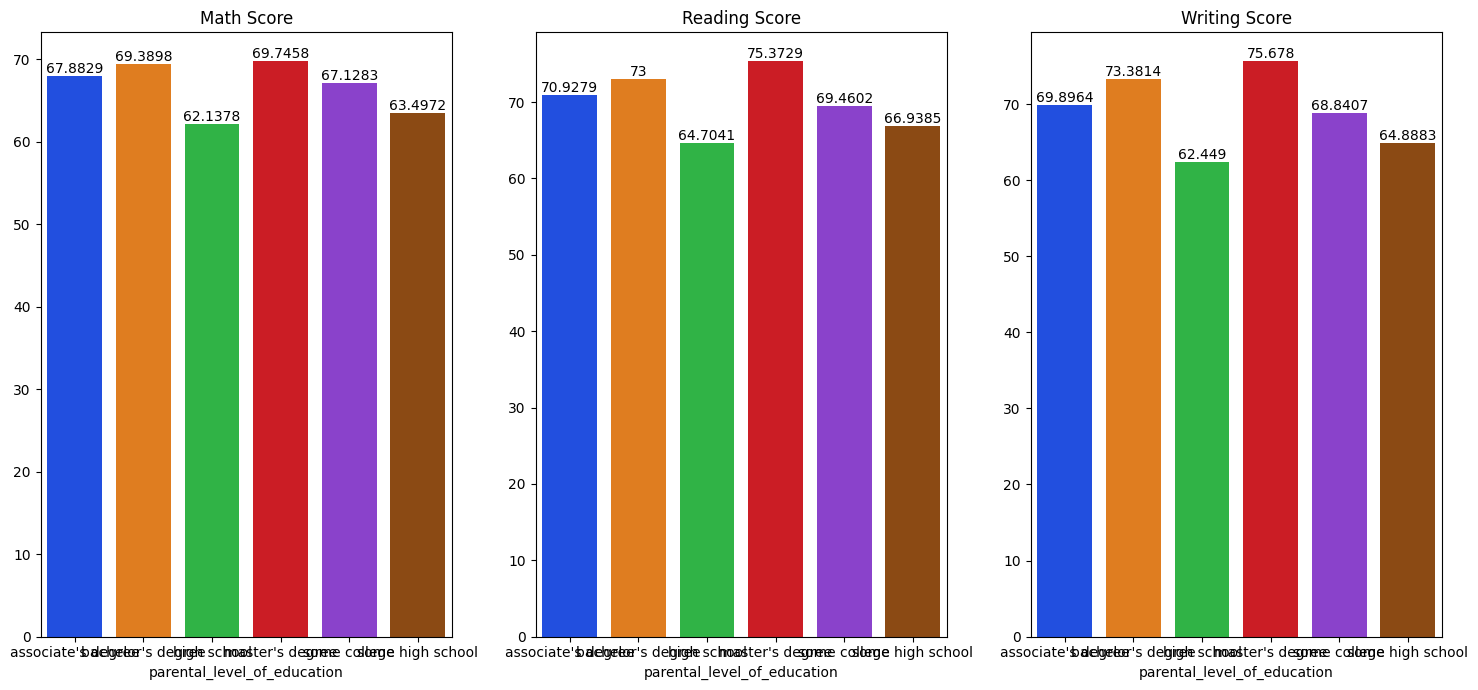

In [119]:
fig, axs=plt.subplots(1,3,figsize=(15,7))
plt.subplot(1,3,1)
plt.title("Math Score")
sns.barplot(x=math_group.index,y=math_group.values, palette='bright', ax=axs[0])

for container in axs[0].containers:
    axs[0].bar_label(container, color='black', size=10)


plt.subplot(1,3,2)
plt.title("Reading Score")
sns.barplot(x=reading_group.index,y=reading_group.values, palette='bright', ax=axs[1])

for container in axs[1].containers:
    axs[1].bar_label(container, color='black', size=10)

plt.subplot(1,3,3)
plt.title("Writing Score")
sns.barplot(x=writing_group.index,y=writing_group.values, palette='bright', ax=axs[2])

for container in axs[2].containers:
    axs[2].bar_label(container, color='black', size=10)


plt.tight_layout()
plt.show()

In [122]:
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score', 'total_score', 'avg_score'],
      dtype='object')

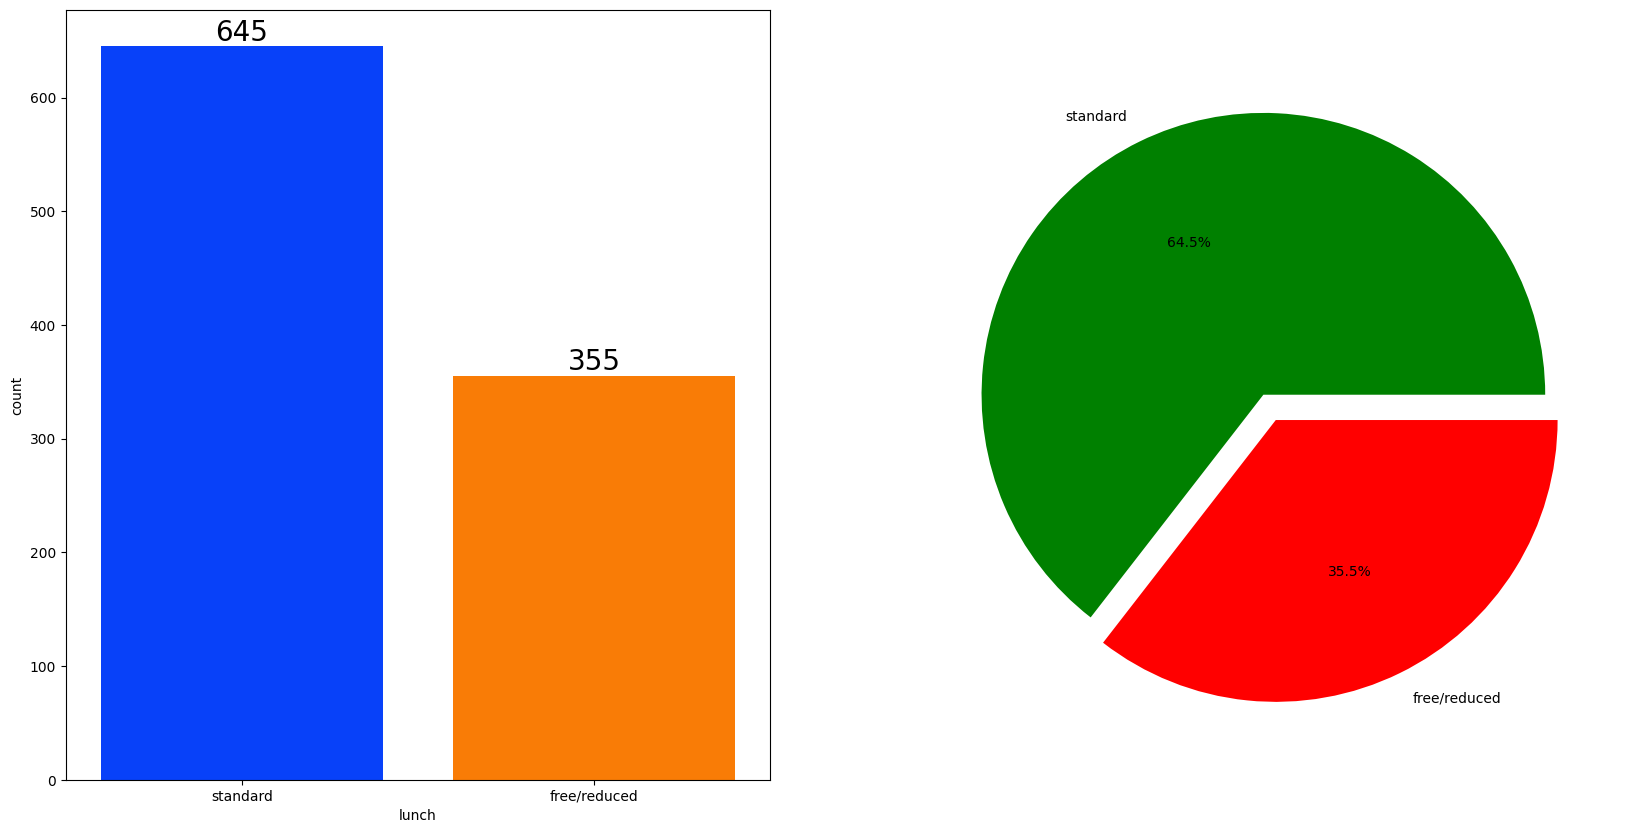

In [126]:
fig, axs=plt.subplots(1,2,figsize=(20,10))
sns.countplot(data=df, x='lunch', palette='bright', ax=axs[0], saturation=0.95)
for container in axs[0].containers:
    axs[0].bar_label(container, size=20)

plt.pie(x=df['lunch'].value_counts(), labels=df['lunch'].unique(), colors=['g','r'], explode=[0,0.1], autopct="%1.1f%%")
plt.show()

In [127]:
math_group=df.groupby('lunch')['math_score'].mean()
reading_group=df.groupby('lunch')['reading_score'].mean()
writing_group=df.groupby('lunch')['writing_score'].mean()

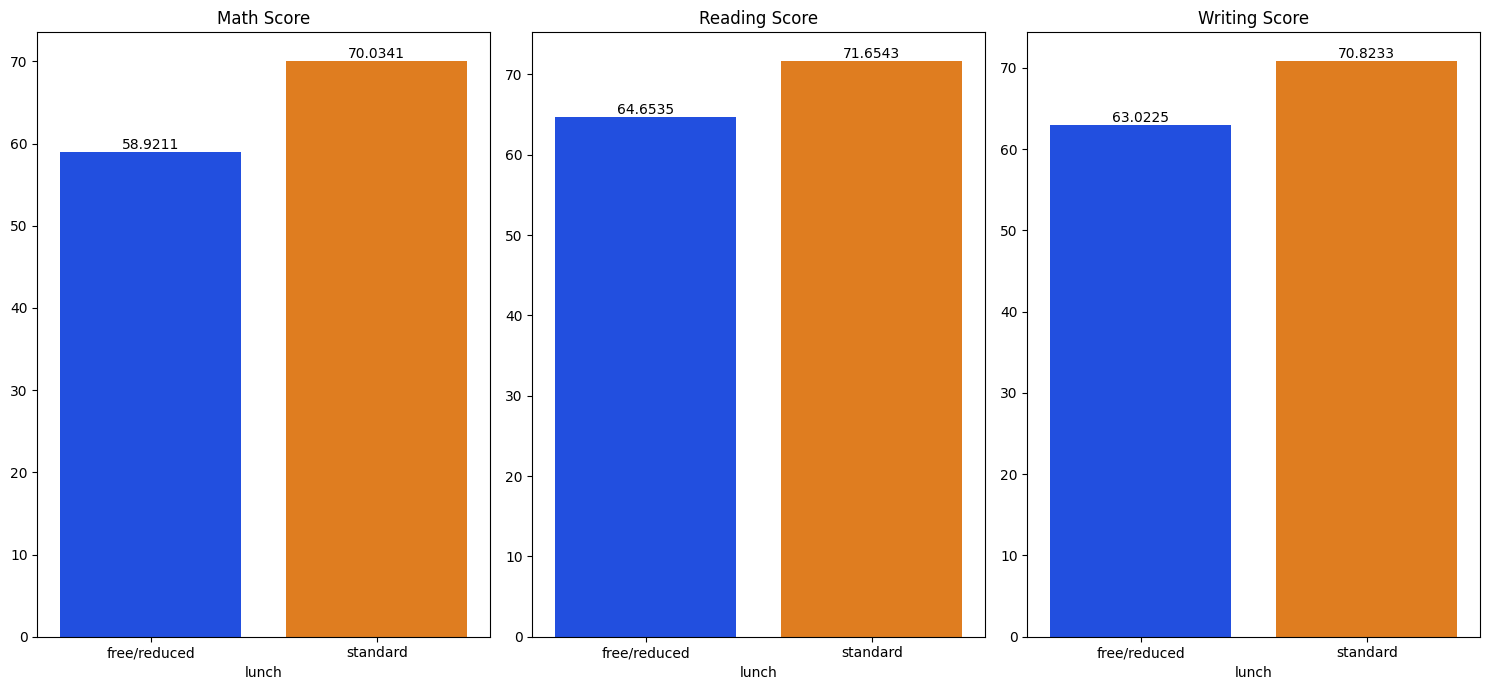

In [128]:
fig, axs=plt.subplots(1,3,figsize=(15,7))
plt.subplot(1,3,1)
plt.title("Math Score")
sns.barplot(x=math_group.index,y=math_group.values, palette='bright', ax=axs[0])

for container in axs[0].containers:
    axs[0].bar_label(container, color='black', size=10)


plt.subplot(1,3,2)
plt.title("Reading Score")
sns.barplot(x=reading_group.index,y=reading_group.values, palette='bright', ax=axs[1])

for container in axs[1].containers:
    axs[1].bar_label(container, color='black', size=10)

plt.subplot(1,3,3)
plt.title("Writing Score")
sns.barplot(x=writing_group.index,y=writing_group.values, palette='bright', ax=axs[2])

for container in axs[2].containers:
    axs[2].bar_label(container, color='black', size=10)


plt.tight_layout()
plt.show()

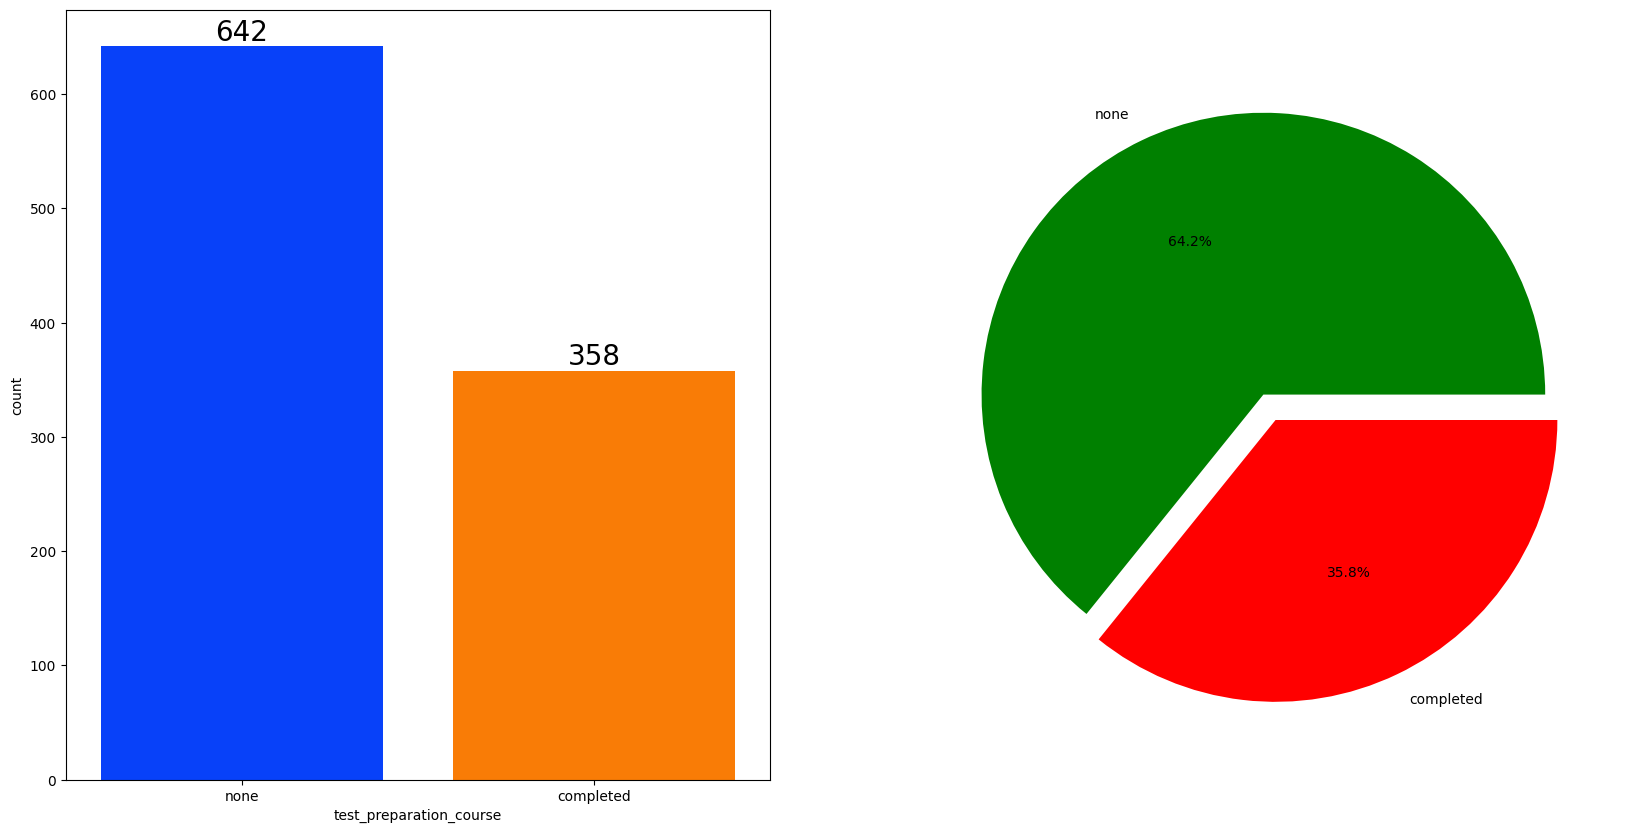

In [129]:
fig, axs=plt.subplots(1,2,figsize=(20,10))
sns.countplot(data=df, x='test_preparation_course', palette='bright', ax=axs[0], saturation=0.95)
for container in axs[0].containers:
    axs[0].bar_label(container, size=20)

plt.pie(x=df['test_preparation_course'].value_counts(), labels=df['test_preparation_course'].unique(), colors=['g','r'], explode=[0,0.1], autopct="%1.1f%%")
plt.show()

In [130]:
math_group=df.groupby('test_preparation_course')['math_score'].mean()
reading_group=df.groupby('test_preparation_course')['reading_score'].mean()
writing_group=df.groupby('test_preparation_course')['writing_score'].mean()

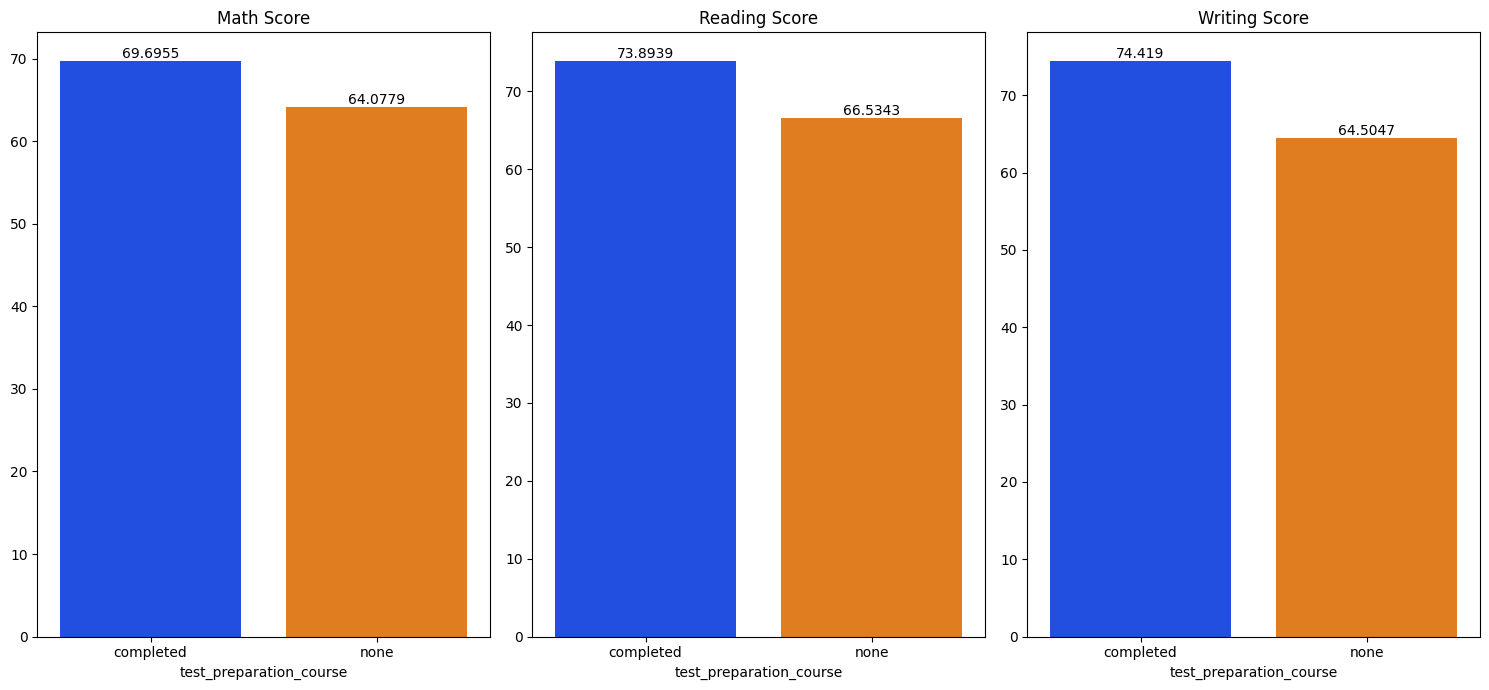

In [131]:
fig, axs=plt.subplots(1,3,figsize=(15,7))
plt.subplot(1,3,1)
plt.title("Math Score")
sns.barplot(x=math_group.index,y=math_group.values, palette='bright', ax=axs[0])

for container in axs[0].containers:
    axs[0].bar_label(container, color='black', size=10)


plt.subplot(1,3,2)
plt.title("Reading Score")
sns.barplot(x=reading_group.index,y=reading_group.values, palette='bright', ax=axs[1])

for container in axs[1].containers:
    axs[1].bar_label(container, color='black', size=10)

plt.subplot(1,3,3)
plt.title("Writing Score")
sns.barplot(x=writing_group.index,y=writing_group.values, palette='bright', ax=axs[2])

for container in axs[2].containers:
    axs[2].bar_label(container, color='black', size=10)


plt.tight_layout()
plt.show()

<Axes: ylabel='avg_score'>

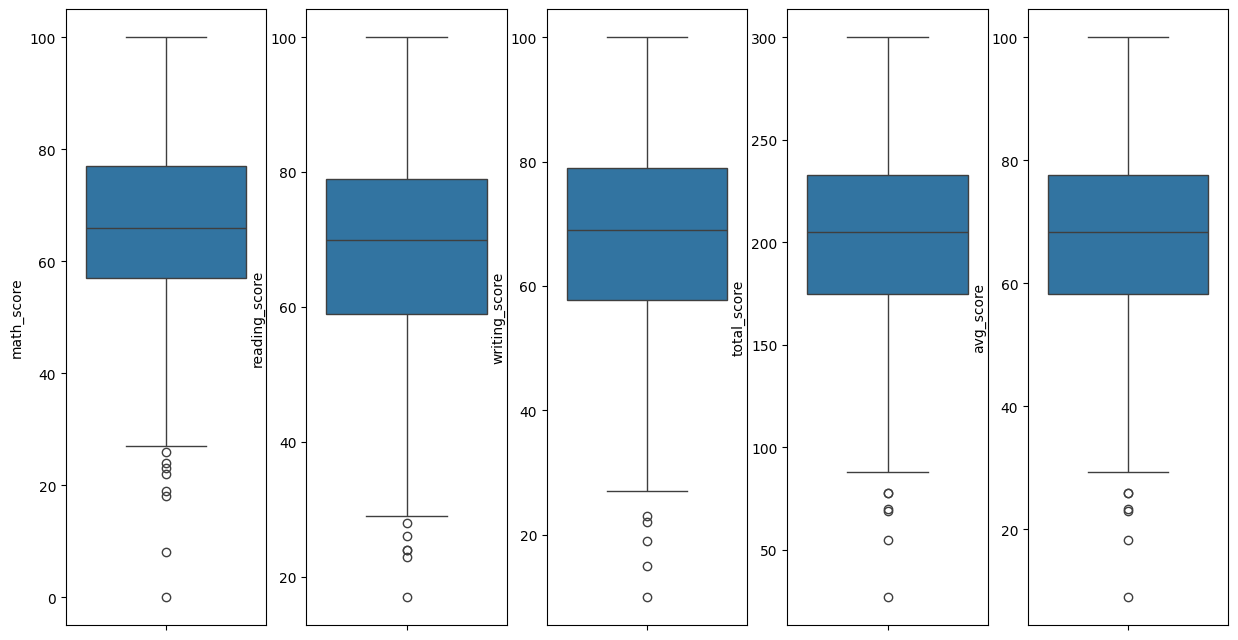

In [134]:
#checking outliers
fig, axs=plt.subplots(1,5,figsize=(15,8))
sns.boxplot(df['math_score'],ax=axs[0])
sns.boxplot(df['reading_score'],ax=axs[1])
sns.boxplot(df['writing_score'],ax=axs[2])
sns.boxplot(df['total_score'],ax=axs[3])
sns.boxplot(df['avg_score'],ax=axs[4])

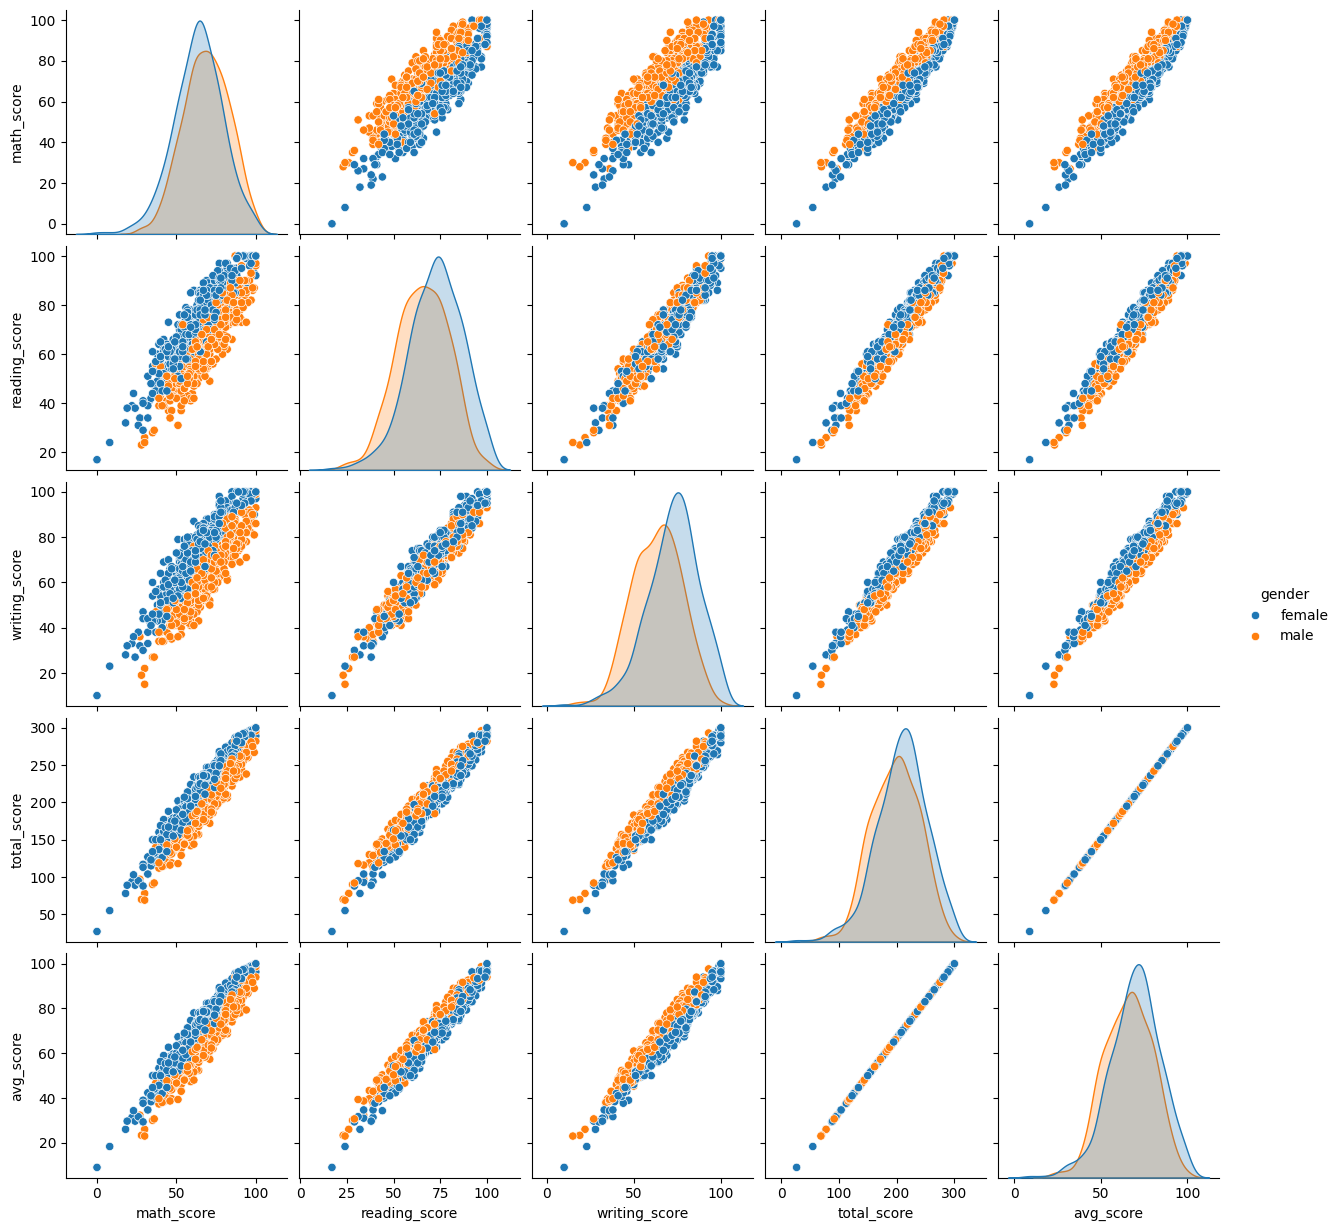

In [135]:
sns.pairplot(df, hue='gender')
#some values increase linearly with others